# Лабораторная работа 4. Решающие деревья и ансамбли моделей

**Датасеты:**
- Классификация: `diabetes_health_indicators` (целевой признак: `Diabetes_012`)
- Регрессия: `moldova_cars_task` (целевой признак: `Price(euro)`)

## Инициализация

In [119]:
import datetime
import json
import time
import warnings
from math import sqrt
from collections import Counter

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    KFold,
    cross_val_score,
    GridSearchCV,
    RandomizedSearchCV
)

from imblearn.over_sampling import SMOTE

from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    export_text
)
from sklearn import tree as sk_tree
from sklearn.ensemble import (
    RandomForestClassifier,   BaggingClassifier,
    GradientBoostingClassifier, StackingClassifier,
    RandomForestRegressor,    BaggingRegressor,
    GradientBoostingRegressor,  StackingRegressor
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_auc_score, roc_curve, auc,
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)

from catboost import CatBoostClassifier, CatBoostRegressor
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor

from scipy.stats import randint, uniform, loguniform

import joblib

warnings.filterwarnings('ignore')


---
# Часть 1. Классификация

**Датасет:** Diabetes Health Indicators  
**Целевая переменная:** `Diabetes_012`
- **0** — нет диабета  
- **1** — предиабет  
- **2** — диабет 2 типа  

**Тип задачи:** Мультиклассовая классификация (3 класса)

## 1. Загрузка и подготовка данных

### 1.1. Загрузка датасета

In [120]:
data_cl = pd.read_csv('../datasets/filtered_diabetes_health_indicators.csv')
print(data_cl.shape)
data_cl.head()

(229718, 22)


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8
3,0,1,0,1,27,0,0,0,1,1,...,1,0,2,0,0,0,0,11,3,6
4,0,1,1,1,24,0,0,0,1,1,...,1,0,2,3,0,0,0,11,5,4


### 1.2. Выделение целевого признака и предикторов

Целевой признак — `Diabetes_012`.

Распределение классов:
Diabetes_012
0    189994
2     35095
1      4629
Name: count, dtype: int64


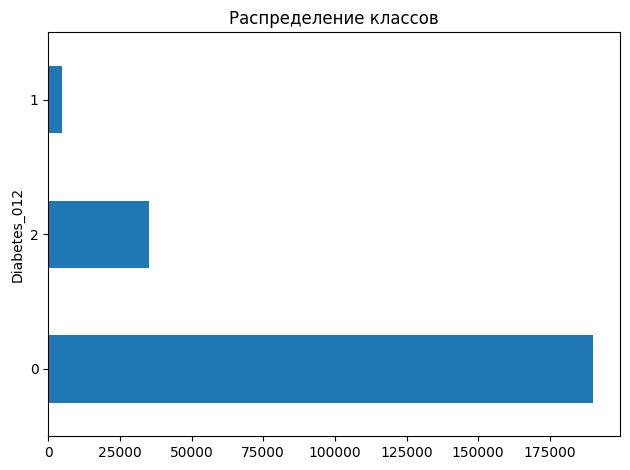

In [121]:
y_cl = data_cl['Diabetes_012']
X_cl = data_cl.drop(columns=['Diabetes_012'])

print("Распределение классов:")
print(y_cl.value_counts())
y_cl.value_counts().plot.barh(title='Распределение классов')
plt.tight_layout()
plt.show()


### 1.3. Разделение на train/test — Hold-out (со стратификацией)

Разделение выполняется **до** масштабирования и балансировки, чтобы исключить утечку данных.

In [122]:
X_train_cl, X_test_cl, y_train_cl, y_test_cl = train_test_split(
    X_cl, y_cl, train_size=0.8, random_state=42, stratify=y_cl
)
print(f"Train: {X_train_cl.shape}, Test: {X_test_cl.shape}")

Train: (183774, 21), Test: (45944, 21)


### 1.4. Масштабирование признаков

In [123]:
scaler_cl = StandardScaler()
X_train_cl_scaled = scaler_cl.fit_transform(X_train_cl)
X_test_cl_scaled  = scaler_cl.transform(X_test_cl)

### 1.5. Балансировка классов (SMOTE)

In [124]:
print("До SMOTE:  ", Counter(y_train_cl))
smote = SMOTE(random_state=42)
X_train_cl_bal, y_train_cl_bal = smote.fit_resample(X_train_cl_scaled, y_train_cl)
print("После SMOTE:", Counter(y_train_cl_bal))

До SMOTE:   Counter({0: 151995, 2: 28076, 1: 3703})
После SMOTE: Counter({0: 151995, 1: 151995, 2: 151995})


### 1.6. K-Fold (кросс-валидация)

In [125]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 1.7. Подвыборка для поиска гиперпараметров

In [126]:
X_search_cl, _, y_search_cl, _ = train_test_split(
    X_train_cl_bal, y_train_cl_bal, train_size=0.05, random_state=42, stratify=y_train_cl_bal
)
X_search_cl.shape

(22799, 21)

### 1.8. Вспомогательные функции

In [127]:
def metrics_cl(y_true, y_pred, prob_array=None):
    print(f"  F1 (weighted): {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Accuracy:      {accuracy_score(y_true, y_pred):.4f}")
    print(f"  Precision (w): {precision_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Recall (w):    {recall_score(y_true, y_pred, average='weighted'):.4f}")
    if prob_array is not None:
        try:
            print(f"  ROC-AUC (ovr): {roc_auc_score(y_true, prob_array, multi_class='ovr'):.4f}")
        except Exception:
            pass

def plot_cm(y_true, y_pred, title='Матрица ошибок'):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, cmap='Blues')
    plt.title(title)
    plt.ylabel('Истинные')
    plt.xlabel('Предсказанные')
    plt.tight_layout()
    plt.show()

def get_row_cl(name, y_true, y_pred, cv_score=None):
    return {
        'Алгоритм':       name,
        'Accuracy':       round(accuracy_score(y_true, y_pred), 4),
        'F1 (weighted)':  round(f1_score(y_true, y_pred, average='weighted'), 4),
        'F1 (macro)':     round(f1_score(y_true, y_pred, average='macro'), 4),
        'Precision (w)':  round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall (w)':     round(recall_score(y_true, y_pred, average='weighted'), 4),
        'CV F1 (mean)':   round(cv_score, 4) if cv_score is not None else '—'
    }


### 1.9. Реализация CART

In [128]:
# Абстрактный базовый класс для метрик и вычисления значения
from abc import ABC, abstractmethod

class TaskStrategy(ABC):
    @abstractmethod
    def compute_metric(self, y):
        pass

    @abstractmethod
    def compute_value(self, y):
        pass

# Стратегия для классификации (Gini)
class ClassificationStrategy(TaskStrategy):
    def compute_metric(self, y):
        counter = Counter(y)
        impurity = 1.0
        for count in counter.values():
            prob = count / len(y)
            impurity -= prob ** 2
        return impurity

    def compute_value(self, y):
        return Counter(y).most_common(1)[0][0]

# Стратегия для регрессии (MSE)
class RegressionStrategy(TaskStrategy):
    def compute_metric(self, y):
        if len(y) == 0:
            return 0
        mean = np.mean(y)
        return np.mean((y - mean) ** 2)

    def compute_value(self, y):
        return np.mean(y)

# Класс узла дерева
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

# Класс CART
class CART:
    def __init__(self, strategy: TaskStrategy, max_depth=None, min_samples_split=2, verbose=True):
        self.strategy = strategy
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.verbose = verbose
        self.root = None
        self._node_count = 0
        self._start_time = None

    def _split_score(self, left_y, right_y):
        return (len(left_y) * self.strategy.compute_metric(left_y) +
                len(right_y) * self.strategy.compute_metric(right_y)) / (len(left_y) + len(right_y))

    def _best_split(self, X, y):
        best_feature, best_threshold, best_score = None, None, float("inf")
        for feature in range(X.shape[1]):
            for threshold in np.unique(X[:, feature]):
                left_mask = X[:, feature] <= threshold
                right_mask = ~left_mask
                left_y, right_y = y[left_mask], y[right_mask]
                if len(left_y) < self.min_samples_split or len(right_y) < self.min_samples_split:
                    continue
                score = self._split_score(left_y, right_y)
                if score < best_score:
                    best_score = score
                    best_feature = feature
                    best_threshold = threshold
        return best_feature, best_threshold, best_score

    def _build_tree(self, X, y, depth=0):
        self._node_count += 1

        if self.verbose and self._node_count % 50 == 0:
            elapsed = time.time() - self._start_time
            print(f"  [CART] узлов построено: {self._node_count:4d} | "
                  f"глубина: {depth} | "
                  f"образцов в узле: {len(y):6d} | "
                  f"прошло: {elapsed:.1f}с",
                  flush=True)

        if (self.max_depth is not None and depth >= self.max_depth) or len(y) < self.min_samples_split:
            return Node(value=self.strategy.compute_value(y))

        feature, threshold, score = self._best_split(X, y)
        if feature is None:
            return Node(value=self.strategy.compute_value(y))

        left_mask = X[:, feature] <= threshold
        left_node  = self._build_tree(X[left_mask],  y[left_mask],  depth + 1)
        right_node = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        return Node(feature=feature, threshold=threshold, left=left_node, right=right_node)

    def fit(self, X, y):
        if isinstance(X, pd.DataFrame): X = X.to_numpy()
        if isinstance(y, (pd.Series, pd.DataFrame)): y = y.to_numpy()
        self._node_count = 0
        self._start_time = time.time()
        if self.verbose:
            print(f"Начало обучения | образцов: {len(y)} | признаков: {X.shape[1]} | max_depth: {self.max_depth}")
        self.root = self._build_tree(X, y)
        elapsed = time.time() - self._start_time
        if self.verbose:
            print(f"Готово | всего узлов: {self._node_count} | время: {elapsed:.1f}с")
        return self

    def _predict_one(self, x, node):
        if node.value is not None:
            return node.value
        if x[node.feature] <= node.threshold:
            return self._predict_one(x, node.left)
        return self._predict_one(x, node.right)

    def predict(self, X):
        if isinstance(X, pd.DataFrame): X = X.to_numpy()
        return np.array([self._predict_one(x, self.root) for x in X])


## 2. Решение задачи классификации

### 2.0. CART — собственная реализация

In [129]:

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение CART")
cart_cl = CART(strategy=ClassificationStrategy(), max_depth=5)
cart_cl.fit(X_train_cl_bal, y_train_cl_bal)
y_pred_cart_cl = cart_cl.predict(X_test_cl_scaled)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

metrics_cl(y_test_cl, y_pred_cart_cl)
plot_cm(y_test_cl, y_pred_cart_cl, 'CART — Матрица ошибок')


[15:18:43] Обучение CART
Начало обучения | образцов: 455985 | признаков: 21 | max_depth: 5


KeyboardInterrupt: 

### 2.1. DecisionTreeClassifier

In [ ]:
dt_cl_grid = {
    'criterion':        ['gini', 'entropy'],
    'max_depth':        [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'class_weight':     [None, 'balanced']
}
gs_dt_cl = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_cl_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_dt_cl.fit(X_search_cl, y_search_cl)
print("GridSearchCV  — best params:", gs_dt_cl.best_params_)
print("GridSearchCV  — best score: ", gs_dt_cl.best_score_)

dt_cl_dist = {
    'criterion':         ['gini', 'entropy', 'log_loss'],
    'max_depth':         randint(3, 30),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf':  randint(1, 20),
    'class_weight':      [None, 'balanced']
}
rs_dt_cl = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_cl_dist, n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
rs_dt_cl.fit(X_search_cl, y_search_cl)
print("\nRandomizedSearchCV — best params:", rs_dt_cl.best_params_)
print("RandomizedSearchCV — best score: ", rs_dt_cl.best_score_)

dt_cl_best = (gs_dt_cl.best_params_
              if gs_dt_cl.best_score_ >= rs_dt_cl.best_score_
              else rs_dt_cl.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение DecisionTreeClassifier")
model_dt_cl = DecisionTreeClassifier(random_state=42, **dt_cl_best)
model_dt_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_dt_cl = model_dt_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_dt_cl)

cv_dt_cl = cross_val_score(model_dt_cl, X_train_cl_bal, y_train_cl_bal,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_dt_cl.mean():.4f} ± {cv_dt_cl.std():.4f}")

In [ ]:
plot_cm(y_test_cl, y_pred_dt_cl, 'DecisionTreeClassifier — Матрица ошибок')

plt.figure(figsize=(22, 9))
sk_tree.plot_tree(
    model_dt_cl,
    feature_names=X_cl.columns.tolist(),
    class_names=['Нет диабета', 'Предиабет', 'Диабет'],
    filled=True, rounded=True, max_depth=3, fontsize=7
)
plt.title('DecisionTreeClassifier (max_depth=3 для отображения)')
plt.tight_layout()
plt.show()

rules_dt_cl = export_text(model_dt_cl, feature_names=list(X_cl.columns))
print("Решающие правила DecisionTreeClassifier (первые 3000 символов):")
print(rules_dt_cl[:3000])

joblib.dump(model_dt_cl, 'dt_classifier.pkl')

### 2.2. RandomForestClassifier

In [ ]:
rf_cl_grid = {
    'n_estimators': [100, 200],
    'criterion':    ['gini', 'entropy'],
    'max_depth':    [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}
gs_rf_cl = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=2),
    rf_cl_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_rf_cl.fit(X_search_cl, y_search_cl)
print("GridSearchCV  — best params:", gs_rf_cl.best_params_)
print("GridSearchCV  — best score: ", gs_rf_cl.best_score_)

rf_cl_dist = {
    'n_estimators':      randint(50, 300),
    'max_depth':         randint(5, 30),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf':  randint(1, 10),
    'criterion':         ['gini', 'entropy'],
    'max_features':      ['sqrt', 'log2']
}
rs_rf_cl = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=2),
    rf_cl_dist, n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
rs_rf_cl.fit(X_search_cl, y_search_cl)
print("\nRandomizedSearchCV — best params:", rs_rf_cl.best_params_)
print("RandomizedSearchCV — best score: ", rs_rf_cl.best_score_)

rf_cl_best = (gs_rf_cl.best_params_
              if gs_rf_cl.best_score_ >= rs_rf_cl.best_score_
              else rs_rf_cl.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение RandomForestClassifier")
model_rf_cl = RandomForestClassifier(random_state=42, n_jobs=2, **rf_cl_best)
model_rf_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_rf_cl = model_rf_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_rf_cl)

cv_rf_cl = cross_val_score(model_rf_cl, X_train_cl_bal, y_train_cl_bal,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_rf_cl.mean():.4f} ± {cv_rf_cl.std():.4f}")

plot_cm(y_test_cl, y_pred_rf_cl, 'RandomForestClassifier — Матрица ошибок')
joblib.dump(model_rf_cl, 'rf_classifier.pkl')

### 2.3. BaggingClassifier

In [ ]:
bc_cl_grid = {
    'n_estimators': [10, 50, 100],
    'max_samples':  [0.5, 0.8, 1.0],
    'max_features': [0.5, 0.8, 1.0],
    'bootstrap':    [True, False]
}
gs_bc_cl = GridSearchCV(
    BaggingClassifier(random_state=42, n_jobs=2),
    bc_cl_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_bc_cl.fit(X_search_cl, y_search_cl)
print("GridSearchCV  — best params:", gs_bc_cl.best_params_)
print("GridSearchCV  — best score: ", gs_bc_cl.best_score_)

bc_cl_dist = {
    'n_estimators': randint(10, 150),
    'max_samples':  uniform(0.5, 0.5),
    'max_features': uniform(0.5, 0.5),
    'bootstrap':    [True, False]
}
rs_bc_cl = RandomizedSearchCV(
    BaggingClassifier(random_state=42, n_jobs=2),
    bc_cl_dist, n_iter=15, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
rs_bc_cl.fit(X_search_cl, y_search_cl)
print("\nRandomizedSearchCV — best params:", rs_bc_cl.best_params_)
print("RandomizedSearchCV — best score: ", rs_bc_cl.best_score_)

bc_cl_best = (gs_bc_cl.best_params_
              if gs_bc_cl.best_score_ >= rs_bc_cl.best_score_
              else rs_bc_cl.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение BaggingClassifier")
model_bc_cl = BaggingClassifier(random_state=42, n_jobs=2, **bc_cl_best)
model_bc_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_bc_cl = model_bc_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_bc_cl)

cv_bc_cl = cross_val_score(model_bc_cl, X_train_cl_bal, y_train_cl_bal,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_bc_cl.mean():.4f} ± {cv_bc_cl.std():.4f}")

plot_cm(y_test_cl, y_pred_bc_cl, 'BaggingClassifier — Матрица ошибок')
joblib.dump(model_bc_cl, 'bc_classifier.pkl')

### 2.4. GradientBoostingClassifier

In [ ]:
gb_cl_grid = {
    'n_estimators':  [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.7, 0.8, 1.0]
}
gs_gb_cl = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_cl_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_gb_cl.fit(X_search_cl, y_search_cl)
print("GridSearchCV  — best params:", gs_gb_cl.best_params_)
print("GridSearchCV  — best score: ", gs_gb_cl.best_score_)

gb_cl_dist = {
    'n_estimators':  randint(50, 200),
    'learning_rate': uniform(0.01, 0.19),
    'max_depth':     randint(2, 8),
    'subsample':     uniform(0.6, 0.4),
    'min_samples_leaf': randint(1, 10)
}
rs_gb_cl = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    gb_cl_dist, n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
rs_gb_cl.fit(X_search_cl, y_search_cl)
print("\nRandomizedSearchCV — best params:", rs_gb_cl.best_params_)
print("RandomizedSearchCV — best score: ", rs_gb_cl.best_score_)

gb_cl_best = (gs_gb_cl.best_params_
              if gs_gb_cl.best_score_ >= rs_gb_cl.best_score_
              else rs_gb_cl.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение GradientBoostingClassifier")
model_gb_cl = GradientBoostingClassifier(random_state=42, **gb_cl_best)
model_gb_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_gb_cl = model_gb_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_gb_cl)

cv_gb_cl = cross_val_score(model_gb_cl, X_train_cl_bal, y_train_cl_bal,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_gb_cl.mean():.4f} ± {cv_gb_cl.std():.4f}")

plot_cm(y_test_cl, y_pred_gb_cl, 'GradientBoostingClassifier — Матрица ошибок')
joblib.dump(model_gb_cl, 'gb_classifier.pkl')


### 2.5. StackingClassifier

In [ ]:
estimators_cl = [
    ('dt',  DecisionTreeClassifier(random_state=42, **dt_cl_best)),
    ('rf',  RandomForestClassifier(random_state=42, n_jobs=2, **rf_cl_best)),
]
model_st_cl = StackingClassifier(
    estimators=estimators_cl,
    final_estimator=LogisticRegression(max_iter=10000, random_state=42),
    n_jobs=2
)

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение StackingClassifier")
model_st_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_st_cl = model_st_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_st_cl)

cv_st_cl = cross_val_score(model_st_cl, X_train_cl_bal, y_train_cl_bal,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_st_cl.mean():.4f} ± {cv_st_cl.std():.4f}")

plot_cm(y_test_cl, y_pred_st_cl, 'StackingClassifier — Матрица ошибок')
joblib.dump(model_st_cl, 'st_classifier.pkl')


### 2.6. CatBoostClassifier

In [ ]:
cb_cl_grid = {
    'iterations':    [100, 200, 300],
    'depth':         [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'l2_leaf_reg':   [3, 5, 7]
}
gs_cb_cl = GridSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    cb_cl_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_cb_cl.fit(X_search_cl, y_search_cl)
print("GridSearchCV  — best params:", gs_cb_cl.best_params_)
print("GridSearchCV  — best score: ", gs_cb_cl.best_score_)

cb_cl_dist = {
    'iterations':    randint(50, 300),
    'depth':         randint(4, 9),
    'learning_rate': uniform(0.05, 0.15),
    'l2_leaf_reg':   randint(3, 8)
}
rs_cb_cl = RandomizedSearchCV(
    CatBoostClassifier(verbose=0, random_state=42),
    cb_cl_dist, n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
rs_cb_cl.fit(X_search_cl, y_search_cl)
print("\nRandomizedSearchCV — best params:", rs_cb_cl.best_params_)
print("RandomizedSearchCV — best score: ", rs_cb_cl.best_score_)

cb_cl_best = (gs_cb_cl.best_params_
              if gs_cb_cl.best_score_ >= rs_cb_cl.best_score_
              else rs_cb_cl.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение CatBoostClassifier")
model_cb_cl = CatBoostClassifier(verbose=0, random_state=42, **cb_cl_best)
model_cb_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_cb_cl = model_cb_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_cb_cl)

cv_cb_cl = cross_val_score(model_cb_cl, X_train_cl_bal, y_train_cl_bal,
                            cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_cb_cl.mean():.4f} ± {cv_cb_cl.std():.4f}")

plot_cm(y_test_cl, y_pred_cb_cl, 'CatBoostClassifier — Матрица ошибок')
joblib.dump(model_cb_cl, 'cb_classifier.pkl')

### 2.7. XGBClassifier

In [ ]:
xgb_cl_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample':     [0.7, 0.8, 1.0]
}
gs_xgb_cl = GridSearchCV(
    XGBClassifier(verbosity=0, random_state=42, eval_metric='mlogloss'),
    xgb_cl_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_xgb_cl.fit(X_search_cl, y_search_cl)
print("GridSearchCV  — best params:", gs_xgb_cl.best_params_)
print("GridSearchCV  — best score: ", gs_xgb_cl.best_score_)

xgb_cl_dist = {
    'n_estimators':     randint(50, 300),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.05, 0.15),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}
rs_xgb_cl = RandomizedSearchCV(
    XGBClassifier(verbosity=0, random_state=42, eval_metric='mlogloss'),
    xgb_cl_dist, n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
rs_xgb_cl.fit(X_search_cl, y_search_cl)
print("\nRandomizedSearchCV — best params:", rs_xgb_cl.best_params_)
print("RandomizedSearchCV — best score: ", rs_xgb_cl.best_score_)

xgb_cl_best = (gs_xgb_cl.best_params_
               if gs_xgb_cl.best_score_ >= rs_xgb_cl.best_score_
               else rs_xgb_cl.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение XGBClassifier")
model_xgb_cl = XGBClassifier(verbosity=0, random_state=42, eval_metric='mlogloss', **xgb_cl_best)
model_xgb_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_xgb_cl = model_xgb_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_xgb_cl)

cv_xgb_cl = cross_val_score(model_xgb_cl, X_train_cl_bal, y_train_cl_bal,
                             cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_xgb_cl.mean():.4f} ± {cv_xgb_cl.std():.4f}")

plot_cm(y_test_cl, y_pred_xgb_cl, 'XGBClassifier — Матрица ошибок')
joblib.dump(model_xgb_cl, 'xgb_classifier.pkl')

### 2.8. LGBMClassifier

In [ ]:
lgbm_cl_grid = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'num_leaves':    [31, 50, 70],
    'subsample':     [0.7, 0.8, 1.0]
}
gs_lgbm_cl = GridSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    lgbm_cl_grid, cv=3, scoring='f1_weighted', n_jobs=-1
)
gs_lgbm_cl.fit(X_search_cl, y_search_cl)
print("GridSearchCV  — best params:", gs_lgbm_cl.best_params_)
print("GridSearchCV  — best score: ", gs_lgbm_cl.best_score_)

lgbm_cl_dist = {
    'n_estimators':     randint(50, 300),
    'learning_rate':    uniform(0.05, 0.15),
    'num_leaves':       randint(20, 80),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}
rs_lgbm_cl = RandomizedSearchCV(
    LGBMClassifier(verbose=-1, random_state=42),
    lgbm_cl_dist, n_iter=20, cv=3, scoring='f1_weighted', n_jobs=-1, random_state=42
)
rs_lgbm_cl.fit(X_search_cl, y_search_cl)
print("\nRandomizedSearchCV — best params:", rs_lgbm_cl.best_params_)
print("RandomizedSearchCV — best score: ", rs_lgbm_cl.best_score_)

lgbm_cl_best = (gs_lgbm_cl.best_params_
                if gs_lgbm_cl.best_score_ >= rs_lgbm_cl.best_score_
                else rs_lgbm_cl.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение LGBMClassifier")
model_lgbm_cl = LGBMClassifier(verbose=-1, random_state=42, **lgbm_cl_best)
model_lgbm_cl.fit(X_train_cl_bal, y_train_cl_bal)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_lgbm_cl = model_lgbm_cl.predict(X_test_cl_scaled)
print("\n--- Hold-out ---")
metrics_cl(y_test_cl, y_pred_lgbm_cl)

cv_lgbm_cl = cross_val_score(model_lgbm_cl, X_train_cl_bal, y_train_cl_bal,
                              cv=skf, scoring='f1_weighted', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  F1 (weighted): {cv_lgbm_cl.mean():.4f} ± {cv_lgbm_cl.std():.4f}")

plot_cm(y_test_cl, y_pred_lgbm_cl, 'LGBMClassifier — Матрица ошибок')
joblib.dump(model_lgbm_cl, 'lgbm_classifier.pkl')

## 3. Сводные таблицы результатов классификации

In [ ]:
results_cl = [
    get_row_cl('CART (собственная реализация)', y_test_cl, y_pred_cart_cl),
    get_row_cl('DecisionTreeClassifier',        y_test_cl, y_pred_dt_cl,   cv_dt_cl.mean()),
    get_row_cl('RandomForestClassifier',        y_test_cl, y_pred_rf_cl,   cv_rf_cl.mean()),
    get_row_cl('BaggingClassifier',             y_test_cl, y_pred_bc_cl,   cv_bc_cl.mean()),
    get_row_cl('GradientBoostingClassifier',    y_test_cl, y_pred_gb_cl,   cv_gb_cl.mean()),
    get_row_cl('StackingClassifier',            y_test_cl, y_pred_st_cl,   cv_st_cl.mean()),
    get_row_cl('CatBoostClassifier',            y_test_cl, y_pred_cb_cl,   cv_cb_cl.mean()),
    get_row_cl('XGBClassifier',                 y_test_cl, y_pred_xgb_cl,  cv_xgb_cl.mean()),
    get_row_cl('LGBMClassifier',                y_test_cl, y_pred_lgbm_cl, cv_lgbm_cl.mean()),
]
df_cl = pd.DataFrame(results_cl)

print("Образец 1. Метрики на тестовой выборке (Hold-out)")
display(df_cl[['Алгоритм','Accuracy','F1 (weighted)','F1 (macro)','Precision (w)','Recall (w)']].round(4))

print("\nОбразец 2. Hold-out vs K-Fold")
df_cl2 = df_cl[['Алгоритм','F1 (weighted)','CV F1 (mean)']].rename(
    columns={'F1 (weighted)': 'Hold-out F1', 'CV F1 (mean)': 'K-Fold F1 (mean)'})
display(df_cl2.round(4))

---
# Часть 2. Регрессия

**Датасет:** Moldova Cars Task  
**Целевая переменная:** `Price(euro)` (цена автомобиля в евро)  
**Тип задачи:** Регрессия

## 4. Загрузка и подготовка данных

### 4.1. Загрузка датасета

In [ ]:
data_r = pd.read_csv('filtered_moldova_cars_task.csv')
print(data_r.shape)
data_r.head()

### 4.2. Выделение целевого признака и предикторов

In [ ]:
y_r = data_r['Price(euro)']
X_r = data_r.drop(columns=['Price(euro)'])

print(f"Признаки: {X_r.shape}")
print(f"Цена: min={y_r.min()}, max={y_r.max()}, mean={y_r.mean():.0f}, median={y_r.median():.0f}")

y_r.hist(bins=60, figsize=(8, 4))
plt.title('Распределение Price(euro)')
plt.xlabel('Цена, евро')
plt.tight_layout()
plt.show()

### 4.3. Разделение на train/test — Hold-out

In [ ]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_r, y_r, test_size=0.2, random_state=42
)
print(f"Train: {X_train_r.shape}, Test: {X_test_r.shape}")

### 4.4. Масштабирование признаков

In [ ]:
scaler_r = StandardScaler()
X_train_r_scaled = scaler_r.fit_transform(X_train_r)
X_test_r_scaled  = scaler_r.transform(X_test_r)

### 4.5. K-Fold (кросс-валидация)

In [ ]:
kf_r = KFold(n_splits=5, shuffle=True, random_state=42)

### 4.6. Подвыборка для поиска гиперпараметров

In [ ]:
X_search_r, _, y_search_r, _ = train_test_split(
    X_train_r_scaled, y_train_r,
    train_size=0.15, random_state=42
)
print(f"Подвыборка для поиска гиперпараметров: {X_search_r.shape}")

### 4.7. Вспомогательные функции

In [ ]:
def metrics_r(y_true, y_pred):
    print(f"  MAE:  {mean_absolute_error(y_true, y_pred):.2f}")
    print(f"  MSE:  {mean_squared_error(y_true, y_pred):.2f}")
    print(f"  RMSE: {sqrt(mean_squared_error(y_true, y_pred)):.2f}")
    print(f"  MAPE: {mean_absolute_percentage_error(y_true, y_pred):.4f}")
    print(f"  R²:   {r2_score(y_true, y_pred):.4f}")

def plot_kde_r(y_true, y_pred, title=''):
    sns.kdeplot(y_pred, color='red',   label='Предсказанные', linewidth=2)
    sns.kdeplot(y_true, color='green', label='Реальные',      linewidth=2)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def get_row_r(name, y_true, y_pred, cv_score=None):
    return {
        'Алгоритм': name,
        'MAE':      round(mean_absolute_error(y_true, y_pred), 2),
        'RMSE':     round(sqrt(mean_squared_error(y_true, y_pred)), 2),
        'MAPE':     round(mean_absolute_percentage_error(y_true, y_pred), 4),
        'R²':       round(r2_score(y_true, y_pred), 4),
        'CV R² (mean)': round(cv_score, 4) if cv_score is not None else '—'
    }

## 5. Решение задачи регрессии

### 5.0. CART — собственная реализация

In [ ]:

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение CART (собственная реализация)")
cart_r = CART(strategy=RegressionStrategy(), max_depth=5)
cart_r.fit(X_train_r_scaled, y_train_r)
y_pred_cart_r = cart_r.predict(X_test_r_scaled)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_cart_r)
plot_kde_r(y_test_r, y_pred_cart_r, 'CART (собственная реализация)')

### 5.1. DecisionTreeRegressor

In [ ]:
dt_r_grid = {
    'criterion':         ['squared_error', 'absolute_error'],
    'max_depth':         [5, 10, 15, None],
    'min_samples_leaf':  [1, 5, 10],
    'min_samples_split': [2, 5, 10]
}
gs_dt_r = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_r_grid, cv=3, scoring='r2', n_jobs=-1
)
gs_dt_r.fit(X_search_r, y_search_r)
print("GridSearchCV  — best params:", gs_dt_r.best_params_)
print("GridSearchCV  — best score: ", gs_dt_r.best_score_)

dt_r_dist = {
    'criterion':         ['squared_error', 'absolute_error', 'friedman_mse'],
    'max_depth':         randint(3, 30),
    'min_samples_split': randint(2, 50),
    'min_samples_leaf':  randint(1, 20),
    'max_features':      [None, 'sqrt', 'log2', 0.5, 0.7],
    'ccp_alpha':         uniform(0.0, 0.02)
}
rs_dt_r = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_r_dist, n_iter=20, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
rs_dt_r.fit(X_search_r, y_search_r)
print("\nRandomizedSearchCV — best params:", rs_dt_r.best_params_)
print("RandomizedSearchCV — best score: ", rs_dt_r.best_score_)

dt_r_best = (gs_dt_r.best_params_
             if gs_dt_r.best_score_ >= rs_dt_r.best_score_
             else rs_dt_r.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение DecisionTreeRegressor")
model_dt_r = DecisionTreeRegressor(random_state=42, **dt_r_best)
model_dt_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_dt_r = model_dt_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_dt_r)
plot_kde_r(y_test_r, y_pred_dt_r, 'DecisionTreeRegressor')

cv_dt_r = cross_val_score(model_dt_r, X_train_r_scaled, y_train_r,
                           cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_dt_r.mean():.4f} ± {cv_dt_r.std():.4f}")

In [ ]:
plt.figure(figsize=(22, 9))
sk_tree.plot_tree(
    model_dt_r,
    feature_names=X_r.columns.tolist(),
    filled=True, rounded=True, max_depth=3, fontsize=7
)
plt.title('DecisionTreeRegressor (max_depth=3 для отображения)')
plt.tight_layout()
plt.show()

rules_dt_r = export_text(model_dt_r, feature_names=list(X_r.columns))
print("Решающие правила DecisionTreeRegressor (первые 3000 символов):")
print(rules_dt_r[:3000])

joblib.dump(model_dt_r, 'dt_regressor.pkl')

### 5.2. RandomForestRegressor

In [ ]:
rf_r_grid = {
    'n_estimators': [100, 200],
    'criterion':    ['squared_error', 'absolute_error'],
    'max_depth':    [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}
gs_rf_r = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=2),
    rf_r_grid, cv=3, scoring='r2', n_jobs=-1
)
gs_rf_r.fit(X_search_r, y_search_r)
print("GridSearchCV  — best params:", gs_rf_r.best_params_)
print("GridSearchCV  — best score: ", gs_rf_r.best_score_)

rf_r_dist = {
    'n_estimators':      randint(50, 500),
    'criterion':         ['squared_error', 'absolute_error'],
    'max_depth':         randint(5, 50),
    'min_samples_split': randint(2, 20),
    'min_samples_leaf':  randint(1, 20),
    'max_features':      uniform(0.1, 0.9),
    'ccp_alpha':         uniform(0.0, 0.02)
}
rs_rf_r = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=2),
    rf_r_dist, n_iter=20, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
rs_rf_r.fit(X_search_r, y_search_r)
print("\nRandomizedSearchCV — best params:", rs_rf_r.best_params_)
print("RandomizedSearchCV — best score: ", rs_rf_r.best_score_)

rf_r_best = (gs_rf_r.best_params_
             if gs_rf_r.best_score_ >= rs_rf_r.best_score_
             else rs_rf_r.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение RandomForestRegressor")
model_rf_r = RandomForestRegressor(random_state=42, n_jobs=2, **rf_r_best)
model_rf_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_rf_r = model_rf_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_rf_r)
plot_kde_r(y_test_r, y_pred_rf_r, 'RandomForestRegressor')

cv_rf_r = cross_val_score(model_rf_r, X_train_r_scaled, y_train_r,
                           cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_rf_r.mean():.4f} ± {cv_rf_r.std():.4f}")

joblib.dump(model_rf_r, 'rf_regressor.pkl')

### 5.3. BaggingRegressor

In [ ]:
br_r_grid = {
    'n_estimators': [10, 50, 100],
    'max_samples':  [0.5, 0.8, 1.0],
    'max_features': [0.5, 0.8, 1.0],
    'bootstrap':    [True, False]
}
gs_br_r = GridSearchCV(
    BaggingRegressor(random_state=42, n_jobs=2),
    br_r_grid, cv=3, scoring='r2', n_jobs=-1
)
gs_br_r.fit(X_search_r, y_search_r)
print("GridSearchCV  — best params:", gs_br_r.best_params_)
print("GridSearchCV  — best score: ", gs_br_r.best_score_)

br_r_dist = {
    'n_estimators': randint(10, 150),
    'max_samples':  uniform(0.5, 0.5),
    'max_features': uniform(0.5, 0.5),
    'bootstrap':    [True, False]
}
rs_br_r = RandomizedSearchCV(
    BaggingRegressor(random_state=42, n_jobs=2),
    br_r_dist, n_iter=15, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
rs_br_r.fit(X_search_r, y_search_r)
print("\nRandomizedSearchCV — best params:", rs_br_r.best_params_)
print("RandomizedSearchCV — best score: ", rs_br_r.best_score_)

br_r_best = (gs_br_r.best_params_
             if gs_br_r.best_score_ >= rs_br_r.best_score_
             else rs_br_r.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение BaggingRegressor")
model_br_r = BaggingRegressor(random_state=42, n_jobs=2, **br_r_best)
model_br_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_br_r = model_br_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_br_r)
plot_kde_r(y_test_r, y_pred_br_r, 'BaggingRegressor')

cv_br_r = cross_val_score(model_br_r, X_train_r_scaled, y_train_r,
                           cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_br_r.mean():.4f} ± {cv_br_r.std():.4f}")

joblib.dump(model_br_r, 'br_regressor.pkl')

### 5.4. GradientBoostingRegressor

In [ ]:
gb_r_grid = {
    'n_estimators':  [50, 100, 150],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth':     [3, 5, 7],
    'subsample':     [0.7, 0.8, 1.0]
}
gs_gb_r = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_r_grid, cv=3, scoring='r2', n_jobs=-1
)
gs_gb_r.fit(X_search_r, y_search_r)
print("GridSearchCV  — best params:", gs_gb_r.best_params_)
print("GridSearchCV  — best score: ", gs_gb_r.best_score_)

gb_r_dist = {
    'n_estimators':     randint(50, 200),
    'learning_rate':    uniform(0.01, 0.19),
    'max_depth':        randint(2, 8),
    'subsample':        uniform(0.6, 0.4),
    'min_samples_leaf': randint(1, 10),
    'max_features':     ['sqrt', 'log2', None]
}
rs_gb_r = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_r_dist, n_iter=20, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
rs_gb_r.fit(X_search_r, y_search_r)
print("\nRandomizedSearchCV — best params:", rs_gb_r.best_params_)
print("RandomizedSearchCV — best score: ", rs_gb_r.best_score_)

gb_r_best = (gs_gb_r.best_params_
             if gs_gb_r.best_score_ >= rs_gb_r.best_score_
             else rs_gb_r.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение GradientBoostingRegressor")
model_gb_r = GradientBoostingRegressor(random_state=42, **gb_r_best)
model_gb_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_gb_r = model_gb_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_gb_r)
plot_kde_r(y_test_r, y_pred_gb_r, 'GradientBoostingRegressor')

cv_gb_r = cross_val_score(model_gb_r, X_train_r_scaled, y_train_r,
                           cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_gb_r.mean():.4f} ± {cv_gb_r.std():.4f}")

joblib.dump(model_gb_r, 'gb_regressor.pkl')

### 5.5. StackingRegressor

In [ ]:
estimators_r = [
    ('dt',  DecisionTreeRegressor(random_state=42, **dt_r_best)),
    ('knn', KNeighborsRegressor(n_neighbors=5)),
]
model_st_r = StackingRegressor(
    estimators=estimators_r,
    final_estimator=SVR(),
    n_jobs=2
)

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение StackingRegressor")
model_st_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_st_r = model_st_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_st_r)
plot_kde_r(y_test_r, y_pred_st_r, 'StackingRegressor')

cv_st_r = cross_val_score(model_st_r, X_train_r_scaled, y_train_r,
                           cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_st_r.mean():.4f} ± {cv_st_r.std():.4f}")

joblib.dump(model_st_r, 'st_regressor.pkl')

### 5.6. CatBoostRegressor

In [ ]:
cb_r_grid = {
    'iterations':    [100, 200, 300],
    'depth':         [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.15],
    'l2_leaf_reg':   [3, 5, 7]
}
gs_cb_r = GridSearchCV(
    CatBoostRegressor(verbose=0, random_state=42),
    cb_r_grid, cv=3, scoring='r2', n_jobs=-1
)
gs_cb_r.fit(X_search_r, y_search_r)
print("GridSearchCV  — best params:", gs_cb_r.best_params_)
print("GridSearchCV  — best score: ", gs_cb_r.best_score_)

cb_r_dist = {
    'iterations':    randint(50, 300),
    'depth':         randint(4, 9),
    'learning_rate': uniform(0.05, 0.15),
    'l2_leaf_reg':   randint(3, 8)
}
rs_cb_r = RandomizedSearchCV(
    CatBoostRegressor(verbose=0, random_state=42),
    cb_r_dist, n_iter=20, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
rs_cb_r.fit(X_search_r, y_search_r)
print("\nRandomizedSearchCV — best params:", rs_cb_r.best_params_)
print("RandomizedSearchCV — best score: ", rs_cb_r.best_score_)

cb_r_best = (gs_cb_r.best_params_
             if gs_cb_r.best_score_ >= rs_cb_r.best_score_
             else rs_cb_r.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение CatBoostRegressor")
model_cb_r = CatBoostRegressor(verbose=0, random_state=42, **cb_r_best)
model_cb_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_cb_r = model_cb_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_cb_r)
plot_kde_r(y_test_r, y_pred_cb_r, 'CatBoostRegressor')

cv_cb_r = cross_val_score(model_cb_r, X_train_r_scaled, y_train_r,
                           cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_cb_r.mean():.4f} ± {cv_cb_r.std():.4f}")

joblib.dump(model_cb_r, 'cb_regressor.pkl')

### 5.7. XGBRegressor

In [ ]:
xgb_r_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.15],
    'subsample':     [0.7, 0.8, 1.0]
}
gs_xgb_r = GridSearchCV(
    XGBRegressor(verbosity=0, random_state=42),
    xgb_r_grid, cv=3, scoring='r2', n_jobs=-1
)
gs_xgb_r.fit(X_search_r, y_search_r)
print("GridSearchCV  — best params:", gs_xgb_r.best_params_)
print("GridSearchCV  — best score: ", gs_xgb_r.best_score_)

xgb_r_dist = {
    'n_estimators':     randint(50, 300),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.05, 0.15),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}
rs_xgb_r = RandomizedSearchCV(
    XGBRegressor(verbosity=0, random_state=42),
    xgb_r_dist, n_iter=20, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
rs_xgb_r.fit(X_search_r, y_search_r)
print("\nRandomizedSearchCV — best params:", rs_xgb_r.best_params_)
print("RandomizedSearchCV — best score: ", rs_xgb_r.best_score_)

xgb_r_best = (gs_xgb_r.best_params_
              if gs_xgb_r.best_score_ >= rs_xgb_r.best_score_
              else rs_xgb_r.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение XGBRegressor")
model_xgb_r = XGBRegressor(verbosity=0, random_state=42, **xgb_r_best)
model_xgb_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_xgb_r = model_xgb_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_xgb_r)
plot_kde_r(y_test_r, y_pred_xgb_r, 'XGBRegressor')

cv_xgb_r = cross_val_score(model_xgb_r, X_train_r_scaled, y_train_r,
                            cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_xgb_r.mean():.4f} ± {cv_xgb_r.std():.4f}")

joblib.dump(model_xgb_r, 'xgb_regressor.pkl')

### 5.8. LGBMRegressor

In [ ]:
lgbm_r_grid = {
    'n_estimators':  [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.15],
    'num_leaves':    [31, 50, 70],
    'subsample':     [0.7, 0.8, 1.0]
}
gs_lgbm_r = GridSearchCV(
    LGBMRegressor(verbose=-1, random_state=42),
    lgbm_r_grid, cv=3, scoring='r2', n_jobs=-1
)
gs_lgbm_r.fit(X_search_r, y_search_r)
print("GridSearchCV  — best params:", gs_lgbm_r.best_params_)
print("GridSearchCV  — best score: ", gs_lgbm_r.best_score_)

lgbm_r_dist = {
    'n_estimators':     randint(50, 300),
    'learning_rate':    uniform(0.05, 0.15),
    'num_leaves':       randint(20, 80),
    'subsample':        uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3)
}
rs_lgbm_r = RandomizedSearchCV(
    LGBMRegressor(verbose=-1, random_state=42),
    lgbm_r_dist, n_iter=20, cv=3, scoring='r2', n_jobs=-1, random_state=42
)
rs_lgbm_r.fit(X_search_r, y_search_r)
print("\nRandomizedSearchCV — best params:", rs_lgbm_r.best_params_)
print("RandomizedSearchCV — best score: ", rs_lgbm_r.best_score_)

lgbm_r_best = (gs_lgbm_r.best_params_
               if gs_lgbm_r.best_score_ >= rs_lgbm_r.best_score_
               else rs_lgbm_r.best_params_)

In [ ]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Обучение LGBMRegressor")
model_lgbm_r = LGBMRegressor(verbose=-1, random_state=42, **lgbm_r_best)
model_lgbm_r.fit(X_train_r_scaled, y_train_r)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Готово")

y_pred_lgbm_r = model_lgbm_r.predict(X_test_r_scaled)
print("\n--- Hold-out ---")
metrics_r(y_test_r, y_pred_lgbm_r)
plot_kde_r(y_test_r, y_pred_lgbm_r, 'LGBMRegressor')

cv_lgbm_r = cross_val_score(model_lgbm_r, X_train_r_scaled, y_train_r,
                             cv=kf_r, scoring='r2', n_jobs=-1)
print(f"\n--- K-Fold (5-fold) ---")
print(f"  R²: {cv_lgbm_r.mean():.4f} ± {cv_lgbm_r.std():.4f}")

joblib.dump(model_lgbm_r, 'lgbm_regressor.pkl')

## 6. Сводные таблицы результатов регрессии

In [ ]:
results_r = [
    get_row_r('CART (собственная реализация)', y_test_r, y_pred_cart_r),
    get_row_r('DecisionTreeRegressor',         y_test_r, y_pred_dt_r,   cv_dt_r.mean()),
    get_row_r('RandomForestRegressor',         y_test_r, y_pred_rf_r,   cv_rf_r.mean()),
    get_row_r('BaggingRegressor',              y_test_r, y_pred_br_r,   cv_br_r.mean()),
    get_row_r('GradientBoostingRegressor',     y_test_r, y_pred_gb_r,   cv_gb_r.mean()),
    get_row_r('StackingRegressor',             y_test_r, y_pred_st_r,   cv_st_r.mean()),
    get_row_r('CatBoostRegressor',             y_test_r, y_pred_cb_r,   cv_cb_r.mean()),
    get_row_r('XGBRegressor',                  y_test_r, y_pred_xgb_r,  cv_xgb_r.mean()),
    get_row_r('LGBMRegressor',                 y_test_r, y_pred_lgbm_r, cv_lgbm_r.mean()),
]
df_r = pd.DataFrame(results_r)

print("Образец 1. Метрики на тестовой выборке (Hold-out)")
display(df_r[['Алгоритм','MAE','RMSE','MAPE','R²']].round(4))

print("\nОбразец 2. Hold-out vs K-Fold")
df_r2 = df_r[['Алгоритм','R²','CV R² (mean)']].rename(
    columns={'R²': 'Hold-out R²', 'CV R² (mean)': 'K-Fold R² (mean)'})
display(df_r2.round(4))